Time column is increasing: True
Missing values:
time    0
0_x     0
dtype: int64


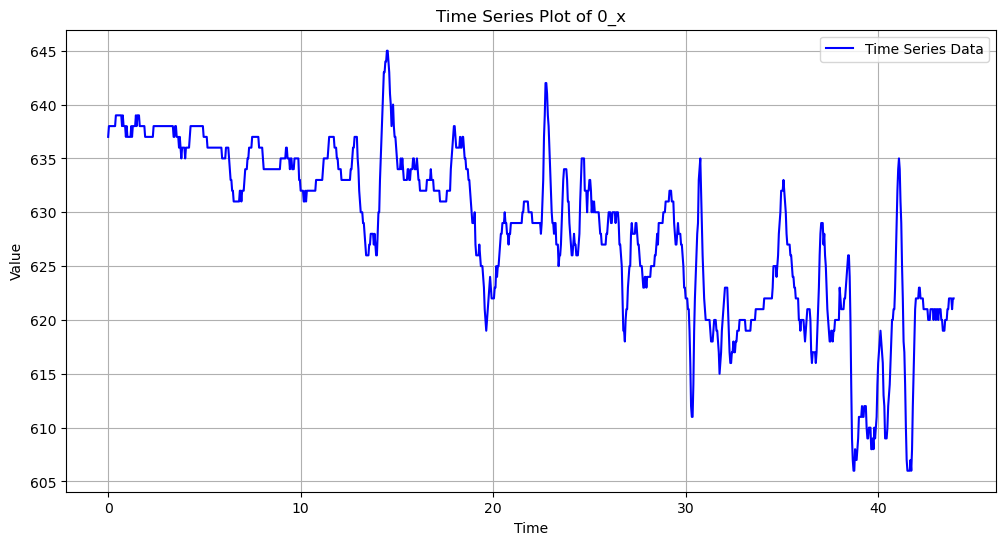

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df['time'].is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Time Series Data", color="blue")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of 0_x")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
# 4. ADF Durağanlık Testi
adf_test = adfuller(df['0_x'])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:", adf_test[4])

# Durağan olup olmadığını kontrol etme
if adf_test[1] < 0.05:
    print("Sonuç: Seri durağandır (Stationary)")
else:
    print("Sonuç: Seri durağan değildir (Non-Stationary)")

ADF Statistic: -2.1645442528685397
p-value: 0.2193645005987338
Critical Values: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}
Sonuç: Seri durağan değildir (Non-Stationary)


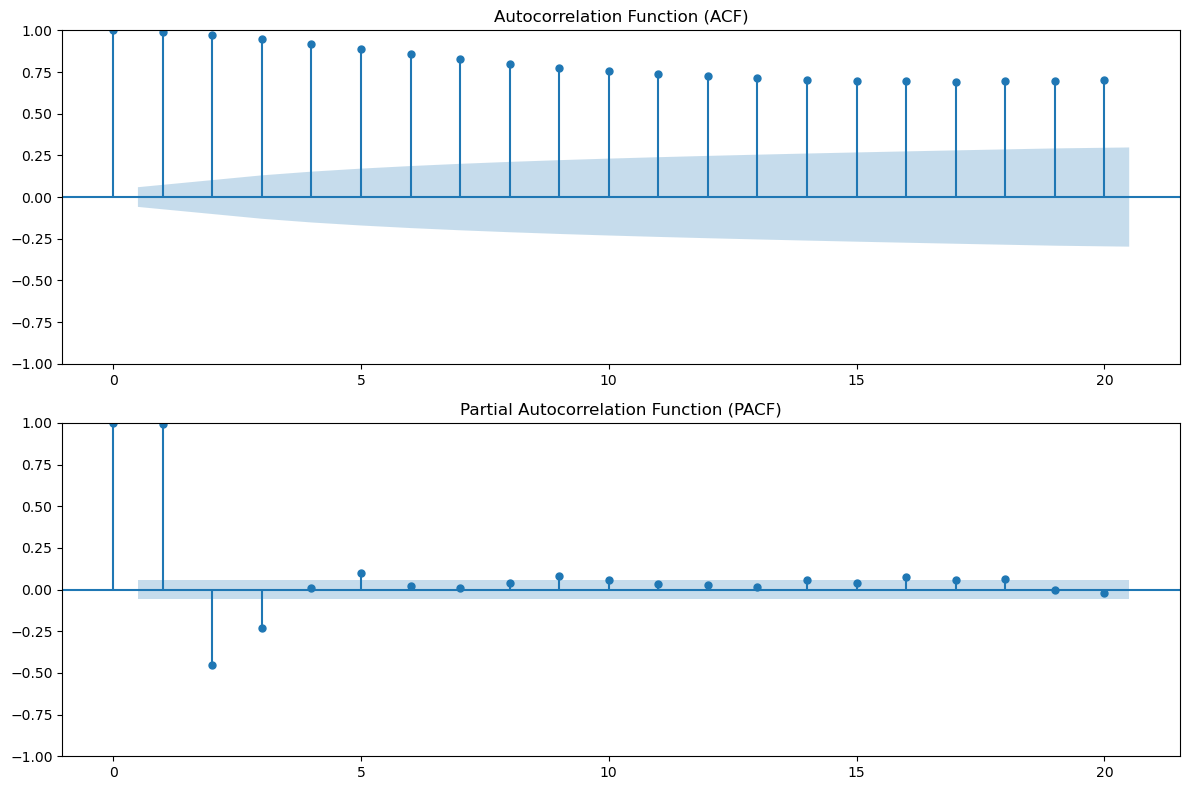

In [3]:
# 5. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['0_x'].dropna(), ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['0_x'].dropna(), ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [4]:
# 6. Durağanlık İçin Fark Alma İşlemi
df['0_x_diff'] = df['0_x'].diff()
adf_test_diff = adfuller(df['0_x_diff'].dropna())
print("ADF Statistic after differencing:", adf_test_diff[0])
print("p-value after differencing:", adf_test_diff[1])

ADF Statistic after differencing: -11.978892038028363
p-value after differencing: 3.745100821121786e-22


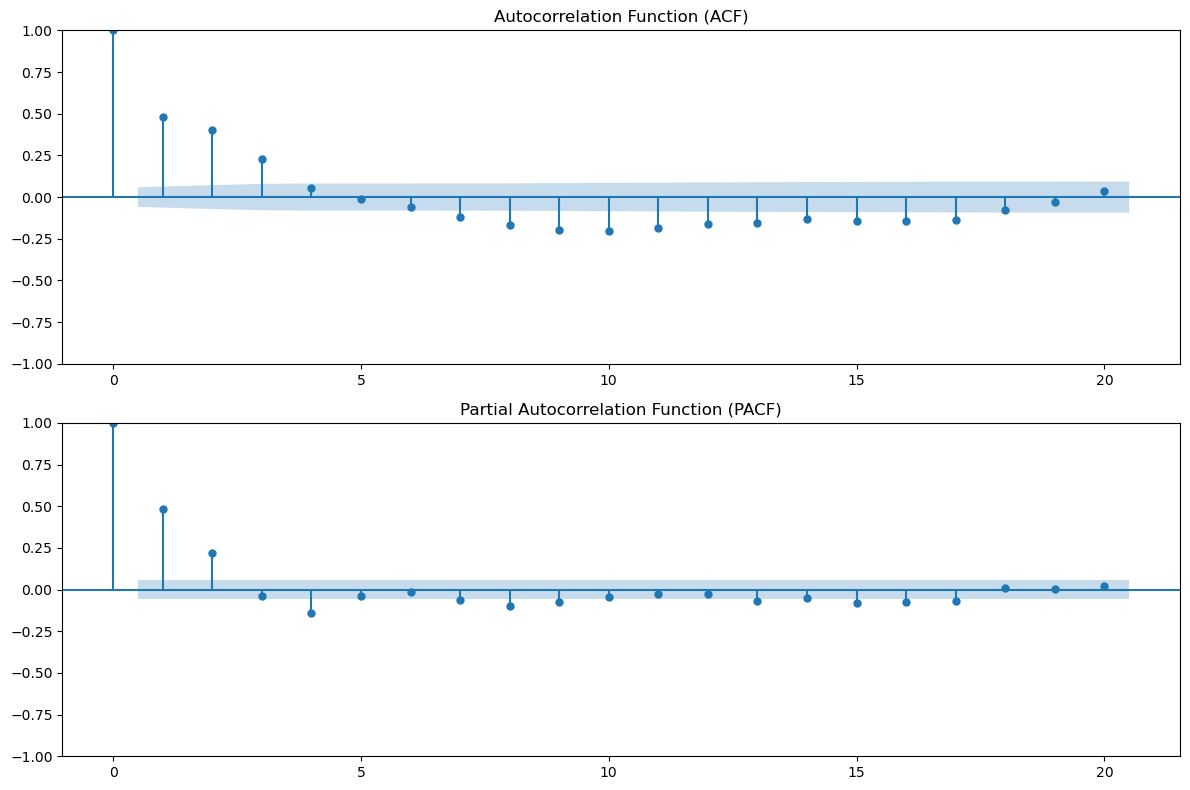

In [5]:
# 7. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df['0_x_diff'].dropna(), ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df['0_x_diff'].dropna(), ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                    0_x   No. Observations:                  879
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1059.926
Date:                Tue, 18 Mar 2025   AIC                           2125.852
Time:                        23:18:01   BIC                           2140.185
Sample:                             0   HQIC                          2131.334
                                - 879                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6741      0.038     17.651      0.000       0.599       0.749
ma.L1         -0.3254      0.046     -7.011      0.000      -0.416      -0.234
sigma2         0.6546      0.021     31.021      0.0

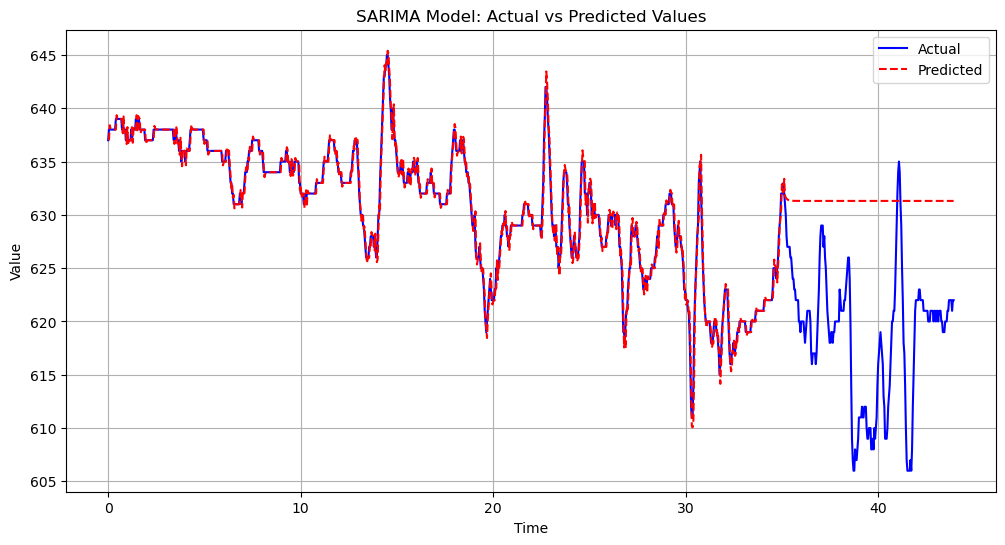

In [6]:
# 8. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]

# 9. Modeli Sadece Train Verisinde Eğitme
model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)) # SARIMA(1,1,1)(0, 0, 0, 0) modeli
model_fit = model.fit()
print(model_fit.summary())

# 10. Test Verisi İçin Tahmin Yapma
predictions = model_fit.forecast(steps=len(test))

# 11. Tahminlerin Görselleştirilmesi
df['predictions'] = model_fit.predict(start=1, end=len(df), dynamic=False)
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['0_x'], label="Actual", color="blue")
plt.plot(df['time'], df['predictions'], label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("SARIMA Model: Actual vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# 12. Performans Metriklerini Hesaplama
actual_values = test.values
predicted_values = predictions.values

mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for actual, predicted in zip(actual_values, predicted_values):
    print(f"Gerçek: {actual}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.7746503594867
Gerçek: 630, Tahmin: 631.6227463100039
Gerçek: 628, Tahmin: 631.5203505830939
Gerçek: 627, Tahmin: 631.4513275061902
Gerçek: 627, Tahmin: 631.4048003190798
Gerçek: 627, Tahmin: 631.3734371976786
Gerçek: 627, Tahmin: 631.3522958941718
Gerçek: 626, Tahmin: 631.3380449301733
Gerçek: 626, Tahmin: 631.3284386173543
Gerçek: 625, Tahmin: 631.3219631785008
Gerçek: 624, Tahmin: 631.3175982042245
Gerçek: 624, Tahmin: 631.3146558553175
Gerçek: 623, Tahmin: 631.3126724720161
Gerçek: 623, Tahmin: 631.3113355097983
Gerçek: 622, Tahmin: 631.3104342881481
Gerçek: 622, Tahmin: 631.3098267912032
Gerçek: 622, Tahmin: 631.3094172886819
Gerçek: 622, Tahmin: 631.3091412505612
Gerçek: 620, Tahmin: 631.3089551783391
Gerçek: 620, Tahmin: 631.3088297504753
Gerçek: 619, Tahmin: 631.3087452018584
Gerçek: 620, Tahmin: 631.3086882091902
Gerçek: 620, Tahmin: 631.3086497914804
Gerçek: 620, Tahmin: 631.3086238948086
Gerçek: 620, Tahmin: 